<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/02_pytorch_classification_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. PyTorch Classification Exercises

The following is a template for 02. PyTorch Classification exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

## Resources
* These exercises are based on [notebook 02 of the learn PyTorch course](https://www.learnpytorch.io/02_pytorch_classification/).
* You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [1]:
# Import torch
import torch

# Setup device agnostic code


# Setup random seed
RANDOM_SEED = 42

## 1. Make a binary classification dataset with Scikit-Learn's [`make_moons()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) function.
  * For consistency, the dataset should have 1000 samples and a `random_state=42`.
  * Turn the data into PyTorch tensors.
  * Split the data into training and test sets using `train_test_split` with 80% training and 20% testing.

In [2]:
# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (1000, 2) y shape: (1000,)


In [3]:
# Turn data into a DataFrame (optional)
import pandas as pd
df = pd.DataFrame(dict(x1=X[:,0], x2=X[:,1], label=y))
df.head()

,x1,x2,label
0,-0.051470,0.444199,1
1,1.032017,-0.419741,1
2,0.867892,-0.254827,1
3,0.288851,-0.448669,1
4,-0.833439,0.535057,0


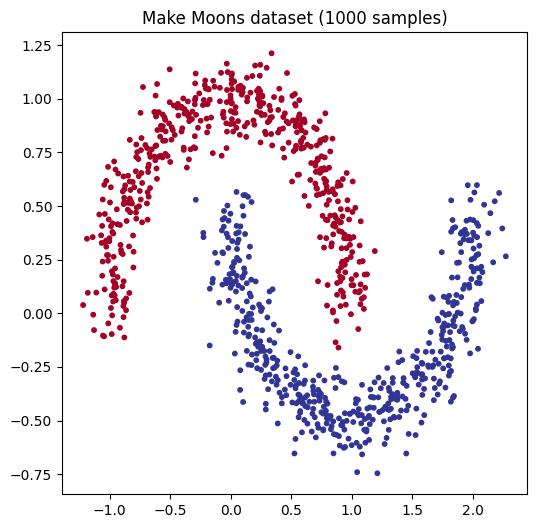

In [4]:
# Visualize the data on a scatter plot
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu, s=10)
plt.title('Make Moons dataset (1000 samples)')
plt.show()

In [5]:
# Turn data into tensors of dtype float and split into train/test
from sklearn.model_selection import train_test_split
import torch
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# convert to tensors
X_train = torch.from_numpy(X_train).float()
X_test = torch.from_numpy(X_test).float()
y_train = torch.from_numpy(y_train).long()
y_test = torch.from_numpy(y_test).long()
print('Train shapes:', X_train.shape, y_train.shape, 'Test shapes:', X_test.shape, y_test.shape)

Train shapes: torch.Size([800, 2]) torch.Size([800]) Test shapes: torch.Size([200, 2]) torch.Size([200])


## 2. Build a model by subclassing `nn.Module` that incorporates non-linear activation functions and is capable of fitting the data you created in 1.
  * Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [6]:
import torch
from torch import nn

# Inherit from nn.Module to make a model capable of fitting the moon data
class MoonModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=2, out_features=8),
            nn.ReLU(),
            nn.Linear(in_features=8, out_features=2) # 2 logits for binary classification
        )
    def forward(self, x):
        return self.net(x)

# Instantiate the model
model = MoonModelV0()
model

MoonModelV0(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=2, bias=True)
  )
)

## 3. Setup a binary classification compatible loss function and optimizer to use when training the model built in 2.

In [7]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

## 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.
  * Do a forward pass of the model to see what's coming out in the form of logits, prediction probabilities and labels.
  * To measure model accuray, you can create your own accuracy function or use the accuracy function in [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/).
  * Train the model for long enough for it to reach over 96% accuracy.
  * The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [8]:
# What's coming out of our model? (logits, probs, labels)
model.eval()
with torch.inference_mode():
    # Use X_test if exists otherwise attempt to use numpy X
    try:
        sample = X_test[:10]
    except NameError:
        import numpy as np
        sample = torch.from_numpy(X[:10]).float()
    logits = model(sample)
    print('Logits:\n', logits)
    probs = torch.softmax(logits, dim=1)
    print('Pred probs:\n', probs)
    preds = torch.argmax(probs, dim=1)
    print('Pred labels:\n', preds)

Logits:
 tensor([[ 0.5997, -0.0711],
        [ 0.7726, -0.3472],
        [ 0.5577, -0.4002],
        [ 0.8760, -0.3389],
        [ 0.5951, -0.6208],
        [ 0.6266, -0.7206],
        [ 0.6969, -0.3733],
        [ 0.6689, -0.3602],
        [ 0.5452, -0.3077],
        [ 0.7773, -0.2639]])
Pred probs:
 tensor([[0.6617, 0.3383],
        [0.7540, 0.2460],
        [0.7227, 0.2773],
        [0.7712, 0.2288],
        [0.7713, 0.2287],
        [0.7937, 0.2063],
        [0.7446, 0.2554],
        [0.7368, 0.2632],
        [0.7012, 0.2988],
        [0.7391, 0.2609]])
Pred labels:
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [9]:
# Let's calculate accuracy manually (no torchmetrics required)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_true)) * 100

# Example usage (if y_test exists)
try:
    with torch.inference_mode():
        sample_logits = model(X_test)
        sample_preds = torch.argmax(torch.softmax(sample_logits, dim=1), dim=1)
        print(f'Example accuracy on test set (untrained): {accuracy_fn(y_test, sample_preds):.2f}%')
except NameError:
    pass

Example accuracy on test set (untrained): 50.00%


In [10]:
# Set random seed for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

# Setup epochs, dataloaders and other hyperparameters
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

epochs = 1000
print('Training for', epochs, 'epochs')

Training for 1000 epochs


## 5. Make predictions with your trained model and plot them using the `plot_decision_boundary()` function created in this notebook.

In [11]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):

    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

In [12]:
# Plot decision boundaries for training and test sets


## 6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
  * Feel free to reference the [ML cheatsheet website](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh) for the formula.

In [13]:
# Create a straight line tensor


In [14]:
# Test torch.tanh() on the tensor and plot it


In [15]:
# Replicate torch.tanh() and plot it


## 7. Create a multi-class dataset using the [spirals data creation function from CS231n](https://cs231n.github.io/neural-networks-case-study/) (see below for the code).
  * Split the data into training and test sets (80% train, 20% test) as well as turn it into PyTorch tensors.
  * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
  * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
  * Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like) - 1000 epochs should be plenty.
  * Plot the decision boundaries on the spirals dataset from your model predictions, the `plot_decision_boundary()` function should work for this dataset too.

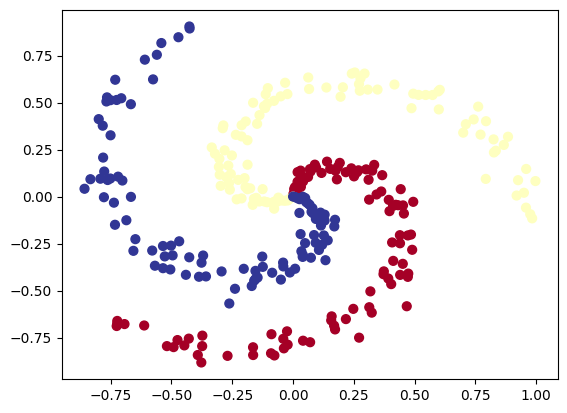

In [16]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [17]:
# (This cell was used earlier) Data already converted to tensors and split in cell 7.
# We keep it as a reminder or could re-run conversion here if necessary.
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [18]:
# Let's calculuate the accuracy for when we fit our model
!pip -q install torchmetrics # colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: uncomment the two lines below to send the accuracy function to the device
# acc_fn = Accuracy(task="multiclass", num_classes=4).to(device)
# acc_fn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.8 MB/s eta 0:00:00


In [19]:
# Prepare device agnostic code
# device = "cuda" if torch.cuda.is_available() else "cpu"

# Create model by subclassing nn.Module



# Instantiate model and send it to device


In [20]:
# Setup data to be device agnostic
device = "cuda" if torch.cuda.is_available() else "mps" if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else "cpu"
print('Using device:', device)
model.to(device);
# Move data to device when running
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Print out first 10 untrained model outputs (forward pass)
print("Logits:")
with torch.inference_mode():
    logits = model(X_test[:10])
    print(logits)

print("Pred probs:")
with torch.inference_mode():
    probs = torch.softmax(logits, dim=1)
    print(probs)

print("Pred labels:")
with torch.inference_mode():
    labels = torch.argmax(probs, dim=1)
    print(labels)

Using device: cuda
Logits:
tensor([[ 0.5997, -0.0711],
        [ 0.7726, -0.3472],
        [ 0.5577, -0.4002],
        [ 0.8760, -0.3389],
        [ 0.5951, -0.6208],
        [ 0.6266, -0.7206],
        [ 0.6969, -0.3733],
        [ 0.6689, -0.3602],
        [ 0.5452, -0.3077],
        [ 0.7773, -0.2639]], device='cuda:0')
Pred probs:
tensor([[0.6617, 0.3383],
        [0.7540, 0.2460],
        [0.7227, 0.2773],
        [0.7712, 0.2288],
        [0.7713, 0.2287],
        [0.7937, 0.2063],
        [0.7446, 0.2554],
        [0.7368, 0.2632],
        [0.7012, 0.2988],
        [0.7391, 0.2609]], device='cuda:0')
Pred labels:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


In [21]:
# Setup loss function and optimizer
# loss_fn =
# optimizer =

In [22]:
# Build a training loop for the model
for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        # 1. Forward pass
        y_logits = model(X_batch)
        # 2. Calculate the loss
        loss = loss_fn(y_logits, y_batch)
        # 3. Optimizer zero grad
        optimizer.zero_grad()
        # 4. Loss backward
        loss.backward()
        # 5. Optimizer step
        optimizer.step()
    # Testing / validation step
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_preds = torch.argmax(torch.softmax(test_logits, dim=1), dim=1)
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_preds)
    # Print out what's happening every 100 epochs
    if epoch % 100 == 0:
        print(f'Epoch: {epoch} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.2f}%')

Epoch: 0 | test_loss: 0.4479 | test_acc: 82.00%
Epoch: 100 | test_loss: 0.1378 | test_acc: 94.50%
Epoch: 200 | test_loss: 0.0305 | test_acc: 99.50%
Epoch: 300 | test_loss: 0.0154 | test_acc: 100.00%
Epoch: 400 | test_loss: 0.0106 | test_acc: 100.00%
Epoch: 500 | test_loss: 0.0080 | test_acc: 100.00%
Epoch: 600 | test_loss: 0.0071 | test_acc: 100.00%
Epoch: 700 | test_loss: 0.0050 | test_acc: 100.00%
Epoch: 800 | test_loss: 0.0046 | test_acc: 100.00%
Epoch: 900 | test_loss: 0.0040 | test_acc: 100.00%


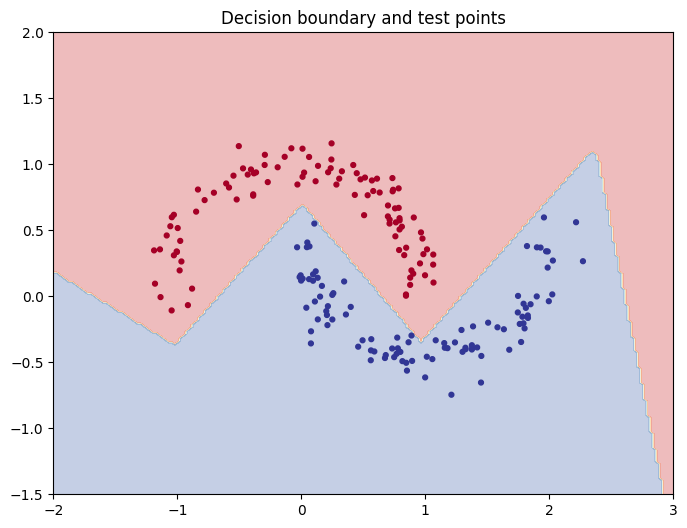

In [23]:
# Plot decision boundaries for training and test sets (visualization)
import matplotlib.pyplot as plt
import numpy as np

# Create a meshgrid over the feature space
xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_t = torch.from_numpy(grid).float().to(device)

model.eval()
with torch.inference_mode():
    logits = model(grid_t)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1).cpu().numpy()

Z = preds.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_test.cpu()[:,0], X_test.cpu()[:,1], c=y_test.cpu(), s=12, cmap=plt.cm.RdYlBu)
plt.title('Decision boundary and test points')
plt.show()